In [4]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"

df = pd.read_csv(url)
df.head()

,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False
1,1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,...,False,False,False,False,False,False,False,False,False,False
2,2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,...,False,False,False,False,False,False,False,False,False,False
3,3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,...,False,False,False,False,False,False,False,False,False,False
4,4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df.shape

(1000, 33)

In [6]:
years = df["Year"].unique()
samples = [df.loc[df["Year"] == y, "Rating"] for y in years]
f, p = stats.f_oneway(*samples)
print(f"f={f:.4f}, p={p:.4f}")

f=6.0455, p=0.0000


In [7]:
dfb = len(years) - 1
dfw = len(df["Rating"]) - len(years)
alpha = 0.05
crit_f = stats.f.ppf(1 - alpha, dfb, dfw)
print(f"f={f:.4f}, critical_f={crit_f:.4f}")

f=6.0455, critical_f=1.8403


In [8]:
sm_tukey = pairwise_tukeyhsd(
   endog = df["Rating"],
   groups = df["Year"],
   alpha = 0.05
)

sm_tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


/var/folders/51/98hfxykd757g35tkvqr8g0r00000gn/T/ipykernel_84936/656259532.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="Year", y="Rating", order=sorted(df["Year"].unique()), ci="sd")


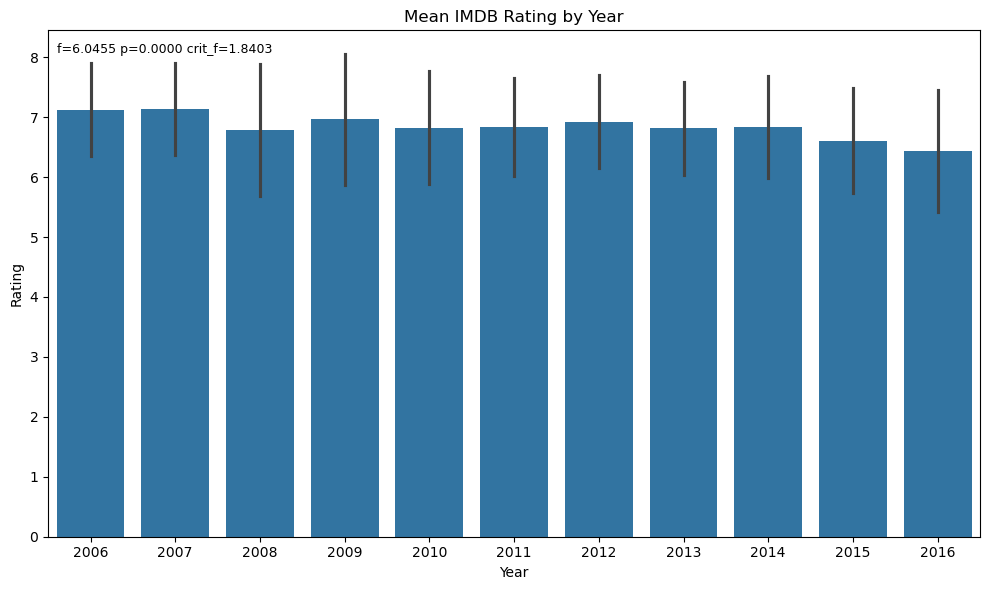

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Year", y="Rating", order=sorted(df["Year"].unique()), ci="sd")
plt.title("Mean IMDB Rating by Year")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.text(
    0.01, 0.95,
    f"f={f:.4f} p={p:.4f} crit_f={crit_f:.4f}",
    transform=plt.gca().transAxes,
    fontsize=9, verticalalignment="bottom",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)
plt.tight_layout()
plt.show()

/var/folders/51/98hfxykd757g35tkvqr8g0r00000gn/T/ipykernel_84936/1184394703.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="Year", y="Rating", hue="Type", order=sorted(df["Year"].unique()), ci="sd")


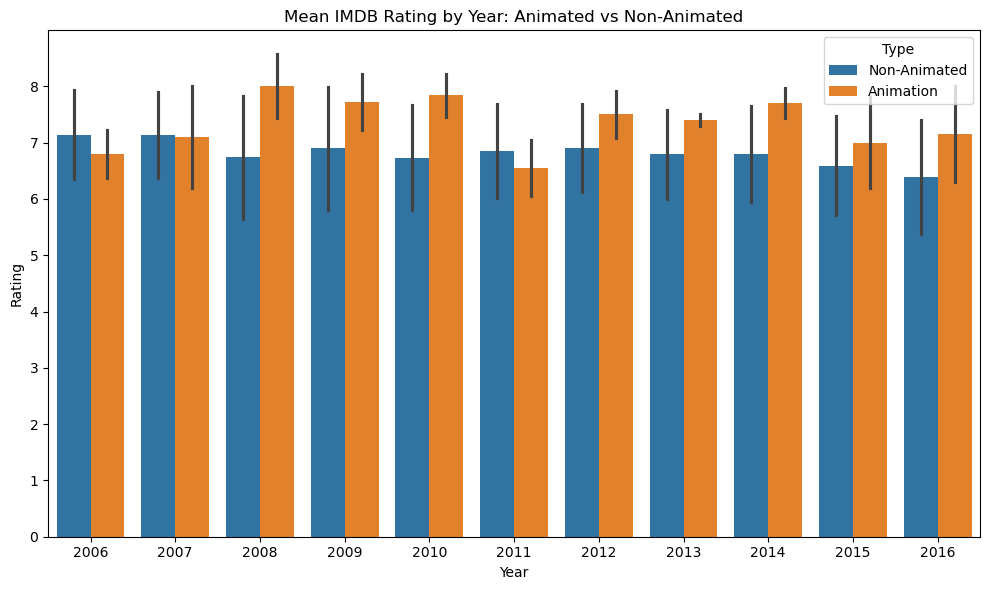

In [12]:
df["Type"] = df["Genre"].str.contains("Animation", na=False).map({True: "Animation", False: "Non-Animated"})

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Year", y="Rating", hue="Type", order=sorted(df["Year"].unique()), ci="sd")
plt.title("Mean IMDB Rating by Year: Animated vs Non-Animated")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

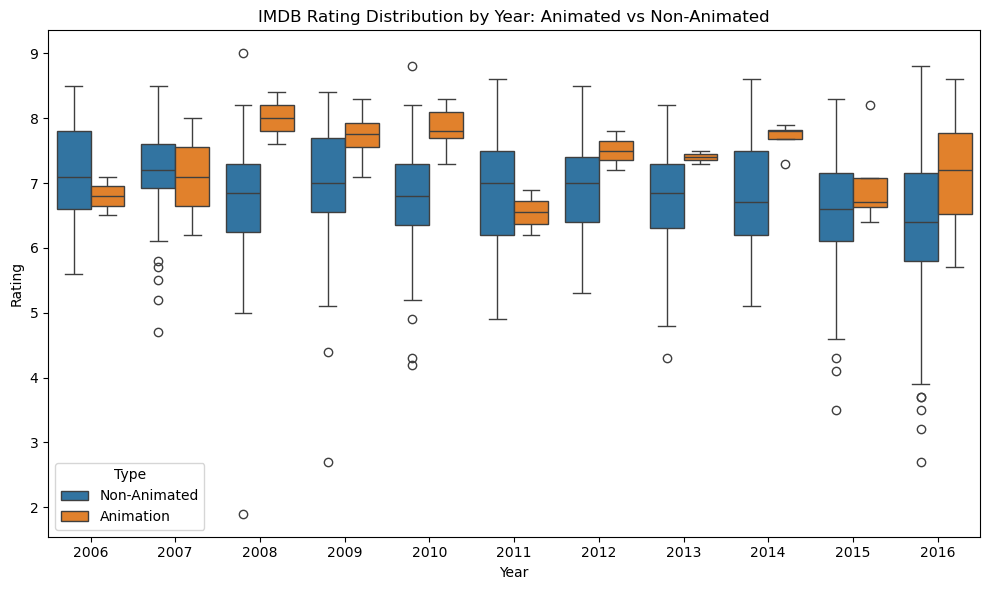

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Year", y="Rating", hue="Type", order=sorted(df["Year"].unique()))
plt.title("IMDB Rating Distribution by Year: Animated vs Non-Animated")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

In [15]:
g1 = df.loc[df["Genre"].str.contains("Action|Adventure|Sci-Fi", na=False), "Rating"]
g2 = df.loc[df["Genre"].str.contains("Drama", na=False), "Rating"]
g3 = df.loc[df["Genre"].str.contains("Comedy|Romance", na=False), "Rating"]
g4 = df.loc[df["Genre"].str.contains("Animation|Adventure|Comedy", na=False), "Rating"]

f2, p2 = stats.f_oneway(g1, g2, g3, g4)
print(f"f={f2:.4f}, p={p2:.4f}")

f=9.7919, p=0.0000


In [17]:
dfb2 = 4 - 1
dfw2 = (len(g1) + len(g2) + len(g3) + len(g4)) - 4
alpha = 0.05
crit_f2 = stats.f.ppf(1 - alpha, dfb2, dfw2)
print(f"f={f2:.4f}, critical_f={crit_f2:.4f}")

f=9.7919, critical_f=2.6099


In [18]:
genre_labels = (["Action/Adv/SciFi"] * len(g1) + ["Drama"] * len(g2) + ["Comedy/Romance"] * len(g3) + ["Animation/Adv/Comedy"] * len(g4))
genre_rating = pd.concat([g1, g2, g3, g4])
sm_tukey2 = pairwise_tukeyhsd(
    endog = genre_rating,
    groups = genre_labels,
    alpha = 0.05
)
sm_tukey2.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Action/Adv/SciFi,Animation/Adv/Comedy,-0.0217,0.9827,-0.1724,0.129,False
Action/Adv/SciFi,Comedy/Romance,-0.0087,0.9991,-0.1727,0.1553,False
Action/Adv/SciFi,Drama,0.2414,0.0002,0.0928,0.39,True
Animation/Adv/Comedy,Comedy/Romance,0.013,0.9968,-0.148,0.1741,False
Animation/Adv/Comedy,Drama,0.2631,0.0,0.1178,0.4085,True
Comedy/Romance,Drama,0.2501,0.0003,0.091,0.4091,True


/var/folders/51/98hfxykd757g35tkvqr8g0r00000gn/T/ipykernel_84936/153133221.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=genre_df, x="Genre Group", y="Rating", ci="sd")


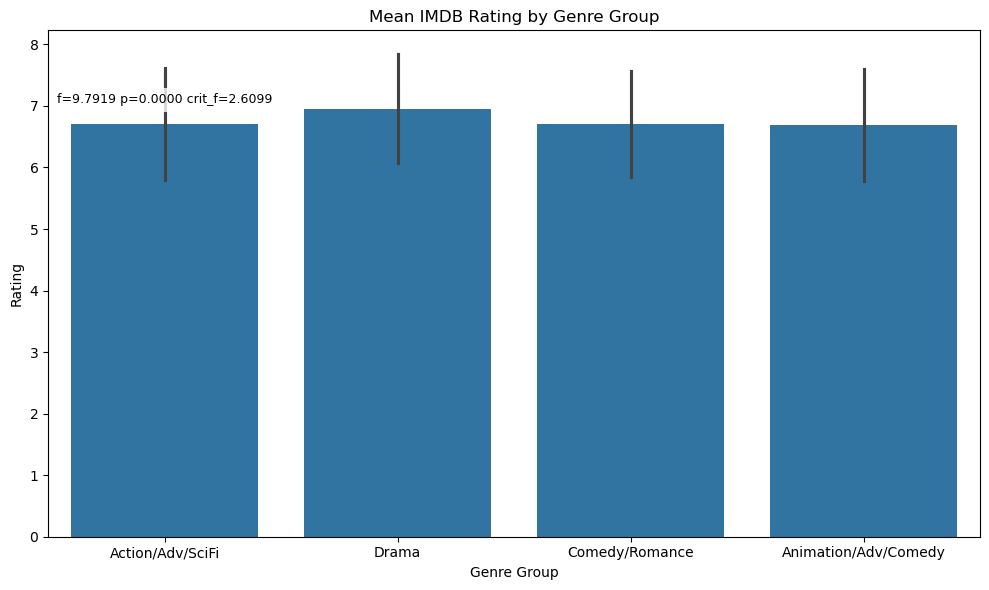

In [23]:
genre_df = pd.DataFrame({"Rating": genre_rating, "Genre Group": genre_labels})

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_df, x="Genre Group", y="Rating", ci="sd")
plt.title("Mean IMDB Rating by Genre Group")
plt.xlabel("Genre Group")
plt.ylabel("Rating")
plt.text(
    0.01, 0.85,
    f"f={f2:.4f} p={p2:.4f} crit_f={crit_f2:.4f}",
    transform=plt.gca().transAxes,
    fontsize=9, verticalalignment="bottom",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()